# HD-MEA Differentiation Simulation

This notebook simulates apoptosis-driven patterning on a 2D MaxTwo-style HD-MEA grid. Each electrode starts as one virtual neuron, then repeated subsampling and distance-kernel scoring remove weakly supported neurons until one third of the initial population remains. The simulation compares an axonal-only exponential model against an ephaptic-axonal model that adds the existing correlation function.

In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "ephax").exists() and (repo_root.parent / "ephax").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax.modeling import HDMEADifferentiationConfig, build_differentiation_simulation, build_kernel_curves, make_hd_mea_grid
from ephax.plotting import PAPER_COLORS, apply_paper_style

apply_paper_style()
plt.rcParams["figure.dpi"] = 120

/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Simulation Parameters

In [2]:
sim_config = HDMEADifferentiationConfig(
    grid_columns=220,
    grid_rows=120,
    pitch_um=17.5,
    hz=45,
    v_eph_m_s=0.1,
    v_ax_m_s=0.8,
    lambda_eph_um=1e4,
    axonal_decay_um=100.0,
    subsample_size=20,
    random_seed=0,
    plating_loss_fraction=0.50,
    target_fraction=0.10,
    milestone_step_fraction=0.10,
)

GRID_COLUMNS = sim_config.grid_columns
GRID_ROWS = sim_config.grid_rows
PITCH_UM = sim_config.pitch_um
HZ = sim_config.hz
V_EPH_M_S = sim_config.v_eph_m_s
V_AX_M_S = sim_config.v_ax_m_s
LAMBDA_EPH_UM = sim_config.lambda_eph_um
AXONAL_DECAY_UM = sim_config.axonal_decay_um
EPHAPTIC_CORRELATION_GAIN = sim_config.correlation_gain
SUBSAMPLE_SIZE = sim_config.subsample_size
RANDOM_SEED = sim_config.random_seed
PLATING_LOSS_FRACTION = sim_config.plating_loss_fraction
TARGET_FRACTION = sim_config.target_fraction
MILESTONE_STEP_FRACTION = sim_config.milestone_step_fraction
MILESTONE_PLOT_ROWS_PER_FIG = 4

INITIAL_COUNT = sim_config.initial_count
PLATING_LOSS_COUNT = sim_config.plating_loss_count
PLATED_COUNT = sim_config.plated_count
TARGET_COUNT = sim_config.target_count
V_EPH_UM_S = sim_config.v_eph_um_s
V_AX_UM_S = sim_config.v_ax_um_s
WAVELENGTH_UM = sim_config.wavelength_um

MODEL_COLORS = {
    "axonal_only": PAPER_COLORS["axonal_only"],
    "ephaptic_axonal": PAPER_COLORS["ephaptic_axonal"],
    "ephaptic_term": PAPER_COLORS["ephaptic_term"],
}
MODEL_LABELS = {
    "axonal_only": "Axonal only",
    "ephaptic_axonal": "Ephaptic-axonal",
}

sim_config.validate()

print(f"Initial neurons: {INITIAL_COUNT:,}")
print(f"Random plating loss: {PLATING_LOSS_COUNT:,} neurons ({PLATING_LOSS_FRACTION:.0%})")
print(f"Plated starting neurons: {PLATED_COUNT:,}")
print(f"Pruning target neurons: {TARGET_COUNT:,} ({TARGET_FRACTION:.1%} of plated count)")
print(f"Expected spatial wavelength: {WAVELENGTH_UM:,.1f} um")
print(f"Axonal-only kernel: exp(-distance / {AXONAL_DECAY_UM:,.0f} um)")
print(f"Ephaptic correlation envelope: exp(-distance / {LAMBDA_EPH_UM:,.0f} um)^2")
print(f"Ephaptic correlation gain: {EPHAPTIC_CORRELATION_GAIN:g}x")
print("Ephaptic-axonal kernel: axonal-only kernel + enveloped ephaptic correlation kernel")

Initial neurons: 26,400
Target neurons: 2,640
Expected spatial wavelength: 2,539.7 um
Axonal-only kernel: exp(-distance / 100 um)
Ephaptic correlation envelope: exp(-distance / 10,000 um)^2
Ephaptic correlation gain: 45x
Ephaptic-axonal kernel: axonal-only kernel + enveloped ephaptic correlation kernel


## Grid Construction

In [3]:
grid = make_hd_mea_grid(sim_config)
coords_um = grid[["x_um", "y_um"]].to_numpy(dtype=float)
active = np.ones(len(grid), dtype=bool)

grid.head()

,electrode,col,row,x_um,y_um
0,0,0,0,0.0,0.0
1,1,1,0,17.5,0.0
2,2,2,0,35.0,0.0
3,3,3,0,52.5,0.0
4,4,4,0,70.0,0.0


## Wavelength Sanity Check

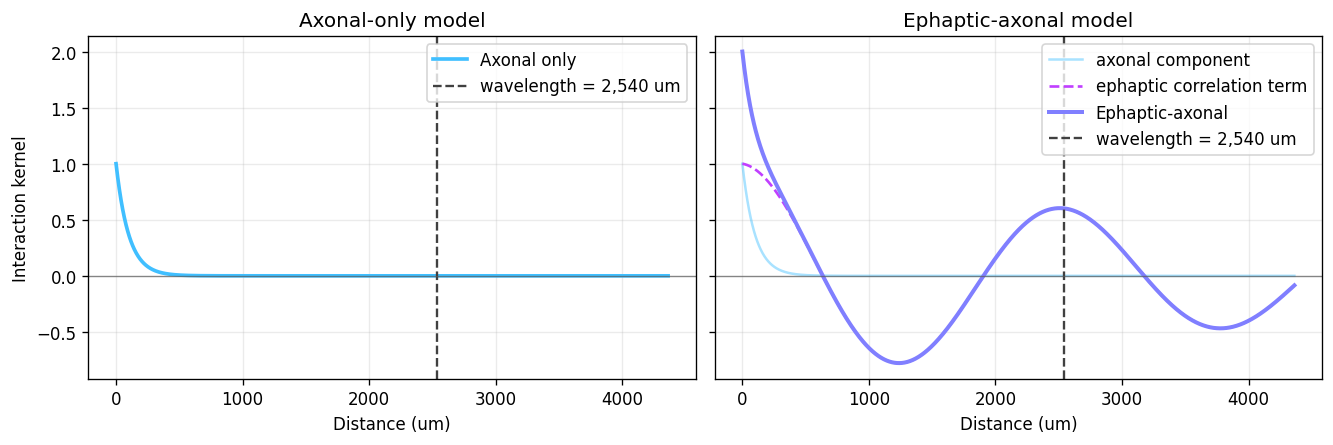

In [4]:
kernels = build_kernel_curves(grid, sim_config)
r_um = kernels["r_um"]
axonal_kernel = kernels["axonal"]
ephaptic_kernel = kernels["ephaptic"]
ephaptic_axonal_kernel = kernels["ephaptic_axonal"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True, sharey=True, constrained_layout=True)

axes[0].plot(r_um, axonal_kernel, color=MODEL_COLORS["axonal_only"], lw=2.2, label=MODEL_LABELS["axonal_only"])
axes[0].axvline(WAVELENGTH_UM, color="0.25", lw=1.4, ls="--", label=f"wavelength = {WAVELENGTH_UM:,.0f} um")
axes[0].axhline(0.0, color="0.35", lw=0.8, alpha=0.7)
axes[0].set_title("Axonal-only model")
axes[0].set_xlabel("Distance (um)")
axes[0].set_ylabel("Interaction kernel")
axes[0].legend(loc="upper right")
axes[0].grid(False)

axes[1].plot(r_um, axonal_kernel, color=MODEL_COLORS["axonal_only"], lw=1.5, alpha=0.45, label="axonal component")
axes[1].plot(r_um, ephaptic_kernel, color=MODEL_COLORS["ephaptic_term"], lw=1.6, ls="--", label="ephaptic correlation term")
axes[1].plot(r_um, ephaptic_axonal_kernel, color=MODEL_COLORS["ephaptic_axonal"], lw=2.4, label=MODEL_LABELS["ephaptic_axonal"])
axes[1].axvline(WAVELENGTH_UM, color="0.25", lw=1.4, ls="--", label=f"wavelength = {WAVELENGTH_UM:,.0f} um")
axes[1].axhline(0.0, color="0.35", lw=0.8, alpha=0.7)
axes[1].set_title("Ephaptic-axonal model")
axes[1].set_xlabel("Distance (um)")
axes[1].legend(loc="upper right")
axes[1].grid(False)
plt.show()

## Apoptosis Simulation

In [5]:
payload = build_differentiation_simulation(
    sim_config,
    model_labels=MODEL_LABELS,
    show_progress=True,
)

grid = payload["grid"]
coords_um = grid[["x_um", "y_um"]].to_numpy(dtype=float)
kernels = payload["kernels"]
r_um = kernels["r_um"]
axonal_kernel = kernels["axonal"]
ephaptic_kernel = kernels["ephaptic"]
ephaptic_axonal_kernel = kernels["ephaptic_axonal"]
milestones = payload["milestones"]
ordered_labels = payload["ordered_labels"]
simulation_results = payload["simulation_results"]
history_df = payload["history_df"]
plated_initial = simulation_results["axonal_only"]["plated_initial"]
final_active = simulation_results["ephaptic_axonal"]["final_active"]
milestone_snapshots = simulation_results["ephaptic_axonal"]["milestone_snapshots"]

history_df

Axonal only apoptosis:   0%|          | 0/23760 [00:00<?, ?neurons/s]

Ephaptic-axonal apoptosis:   0%|          | 0/23760 [00:00<?, ?neurons/s]

,model,round,active_before,active_after,sampled,eliminated,score_mean,score_median,score_max,axonal_score_mean,correlation_score_mean
0,Axonal only,1,26400,26390,20,10,0.121400,0.114518,0.271521,0.121400,0.000000
1,Axonal only,2,26390,26380,20,10,0.133498,0.117931,0.389583,0.133498,0.000000
2,Axonal only,3,26380,26370,20,10,0.077861,0.040386,0.384131,0.077861,0.000000
3,Axonal only,4,26370,26360,20,10,0.198401,0.062468,0.867659,0.198401,0.000000
4,Axonal only,5,26360,26350,20,10,0.098349,0.051098,0.441679,0.098349,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
4747,Ephaptic-axonal,2372,2690,2680,20,10,4.160587,4.388287,8.282348,0.267437,3.893149
4748,Ephaptic-axonal,2373,2680,2670,20,10,5.607153,6.553737,9.441256,0.311261,5.295892
4749,Ephaptic-axonal,2374,2670,2660,20,10,2.235550,3.913481,6.636832,0.319376,1.916174
4750,Ephaptic-axonal,2375,2660,2650,20,10,-0.092750,0.395977,4.434022,0.241206,-0.333956


## Simulation Summary

,model,round,active_before,active_after,sampled,eliminated,score_mean,score_median,score_max,axonal_score_mean,correlation_score_mean
0,Axonal only,2372,2690,2680,20,10,0.141769,0.061838,0.645407,0.141769,0.000000
1,Axonal only,2373,2680,2670,20,10,0.213976,0.061856,0.613852,0.213976,0.000000
2,Axonal only,2374,2670,2660,20,10,0.150543,0.073457,0.548948,0.150543,0.000000
3,Axonal only,2375,2660,2650,20,10,0.124296,0.031403,0.897070,0.124296,0.000000
4,Axonal only,2376,2650,2640,20,10,0.090400,0.066957,0.259341,0.090400,0.000000
5,Ephaptic-axonal,2372,2690,2680,20,10,4.160587,4.388287,8.282348,0.267437,3.893149
6,Ephaptic-axonal,2373,2680,2670,20,10,5.607153,6.553737,9.441256,0.311261,5.295892
7,Ephaptic-axonal,2374,2670,2660,20,10,2.235550,3.913481,6.636832,0.319376,1.916174
8,Ephaptic-axonal,2375,2660,2650,20,10,-0.092750,0.395977,4.434022,0.241206,-0.333956
9,Ephaptic-axonal,2376,2650,2640,20,10,5.023900,6.585448,9.785991,0.389758,4.634142


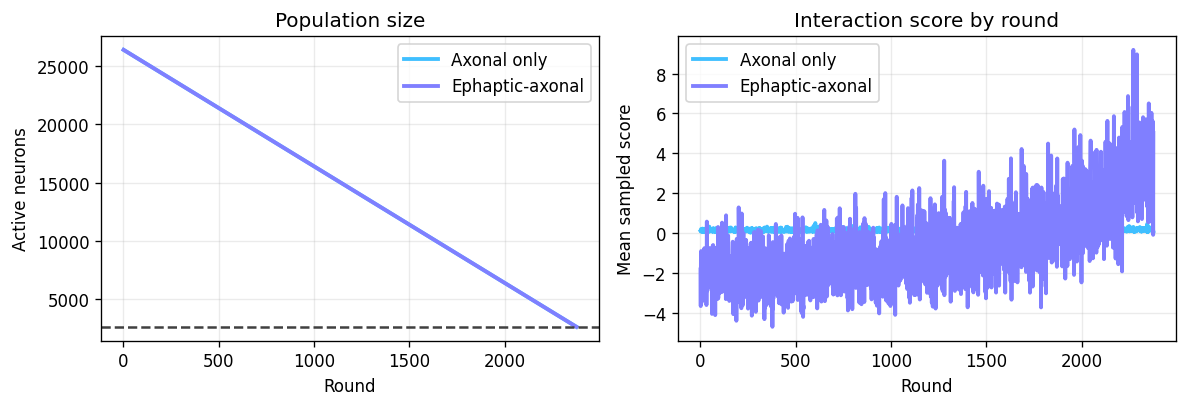

In [6]:
display(history_df.groupby("model").tail(5).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for model_name, model_history in history_df.groupby("model"):
    model_key = "axonal_only" if model_name == MODEL_LABELS["axonal_only"] else "ephaptic_axonal"
    axes[0].plot(
        model_history["round"],
        model_history["active_after"],
        color=MODEL_COLORS[model_key],
        lw=2.3,
        label=model_name,
    )
axes[0].axhline(TARGET_COUNT, color="0.25", ls="--", lw=1.5)
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Active neurons")
axes[0].set_title("Population size")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.25)

for model_name, model_history in history_df.groupby("model"):
    model_key = "axonal_only" if model_name == MODEL_LABELS["axonal_only"] else "ephaptic_axonal"
    axes[1].plot(
        model_history["round"],
        model_history["score_mean"],
        color=MODEL_COLORS[model_key],
        lw=2.3,
        label=model_name,
    )
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Mean sampled score")
axes[1].set_title("Interaction score by round")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## Plating and Final Spatial Pattern

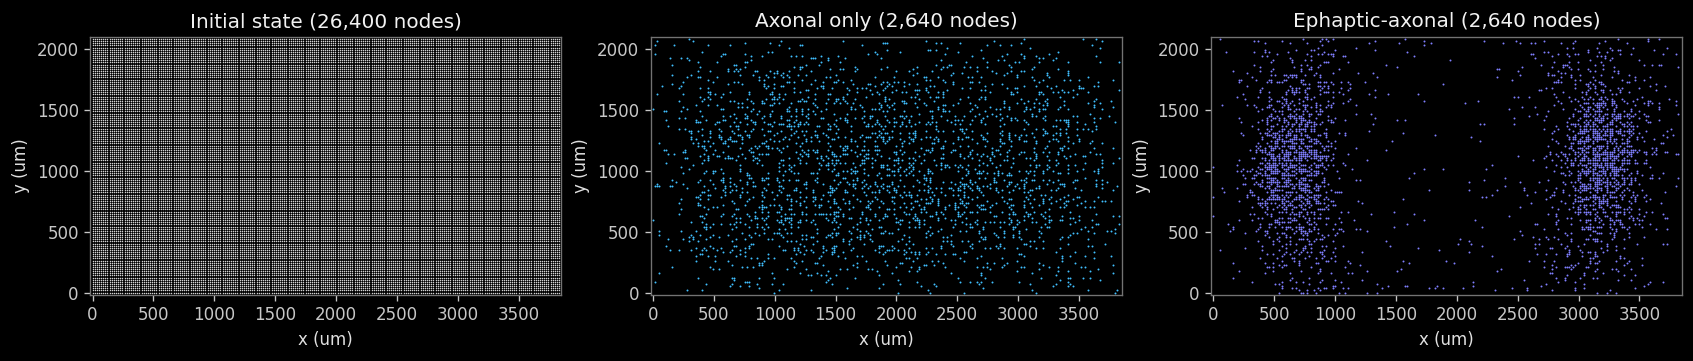

In [7]:
def plot_node_map(ax, nodes_df, title, *, point_size=1.5, color="white", background=None):
    ax.set_facecolor("black")
    if background is not None:
        ax.scatter(background["x_um"], background["y_um"], s=0.05, color="0.20", linewidths=0, rasterized=True)
    ax.scatter(nodes_df["x_um"], nodes_df["y_um"], s=point_size, color=color, linewidths=0, rasterized=True)
    ax.set_aspect("equal")
    ax.set_xlim(-PITCH_UM, grid["x_um"].max() + PITCH_UM)
    ax.set_ylim(-PITCH_UM, grid["y_um"].max() + PITCH_UM)
    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")
    ax.set_title(title)


fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), constrained_layout=True)
plot_node_map(axes[0], grid, f"Initial state ({INITIAL_COUNT:,} nodes)", point_size=0.8, color="0.82")
plot_node_map(
    axes[1],
    plated_initial,
    f"After random plating ({PLATED_COUNT:,} nodes)",
    point_size=1.0,
    color="0.82",
)
plot_node_map(
    axes[2],
    simulation_results["axonal_only"]["final_active"],
    f"Axonal only ({TARGET_COUNT:,} nodes)",
    point_size=1.4,
    color=MODEL_COLORS["axonal_only"],
    background=plated_initial,
)
plot_node_map(
    axes[3],
    simulation_results["ephaptic_axonal"]["final_active"],
    f"Ephaptic-axonal ({TARGET_COUNT:,} nodes)",
    point_size=1.4,
    color=MODEL_COLORS["ephaptic_axonal"],
    background=plated_initial,
)
plt.show()

## Milestone Maps

`milestone_snapshots` stores the remaining-node maps at the first round that drops below each decile threshold, plus the final one-third state.

In [8]:
snapshot_summary = pd.DataFrame(
    [
        {
            "model": result["model"],
            "milestone": label,
            "threshold": milestones[label],
            "remaining_nodes": len(nodes),
        }
        for result in simulation_results.values()
        for label, nodes in result["milestone_snapshots"].items()
    ]
)
snapshot_summary["milestone"] = pd.Categorical(snapshot_summary["milestone"], categories=ordered_labels, ordered=True)
snapshot_summary = snapshot_summary.sort_values(["milestone", "model"]).reset_index(drop=True)
snapshot_summary


,model,milestone,threshold,remaining_nodes
0,Axonal only,90%,23760,23760
1,Axonal only,80%,21120,21120
2,Axonal only,70%,18480,18480
3,Axonal only,60%,15840,15840
4,Axonal only,50%,13200,13200
5,Axonal only,40%,10560,10560
6,Axonal only,10.0%,2640,2640
7,Ephaptic-axonal,90%,23760,23760
8,Ephaptic-axonal,80%,21120,21120
9,Ephaptic-axonal,70%,18480,18480


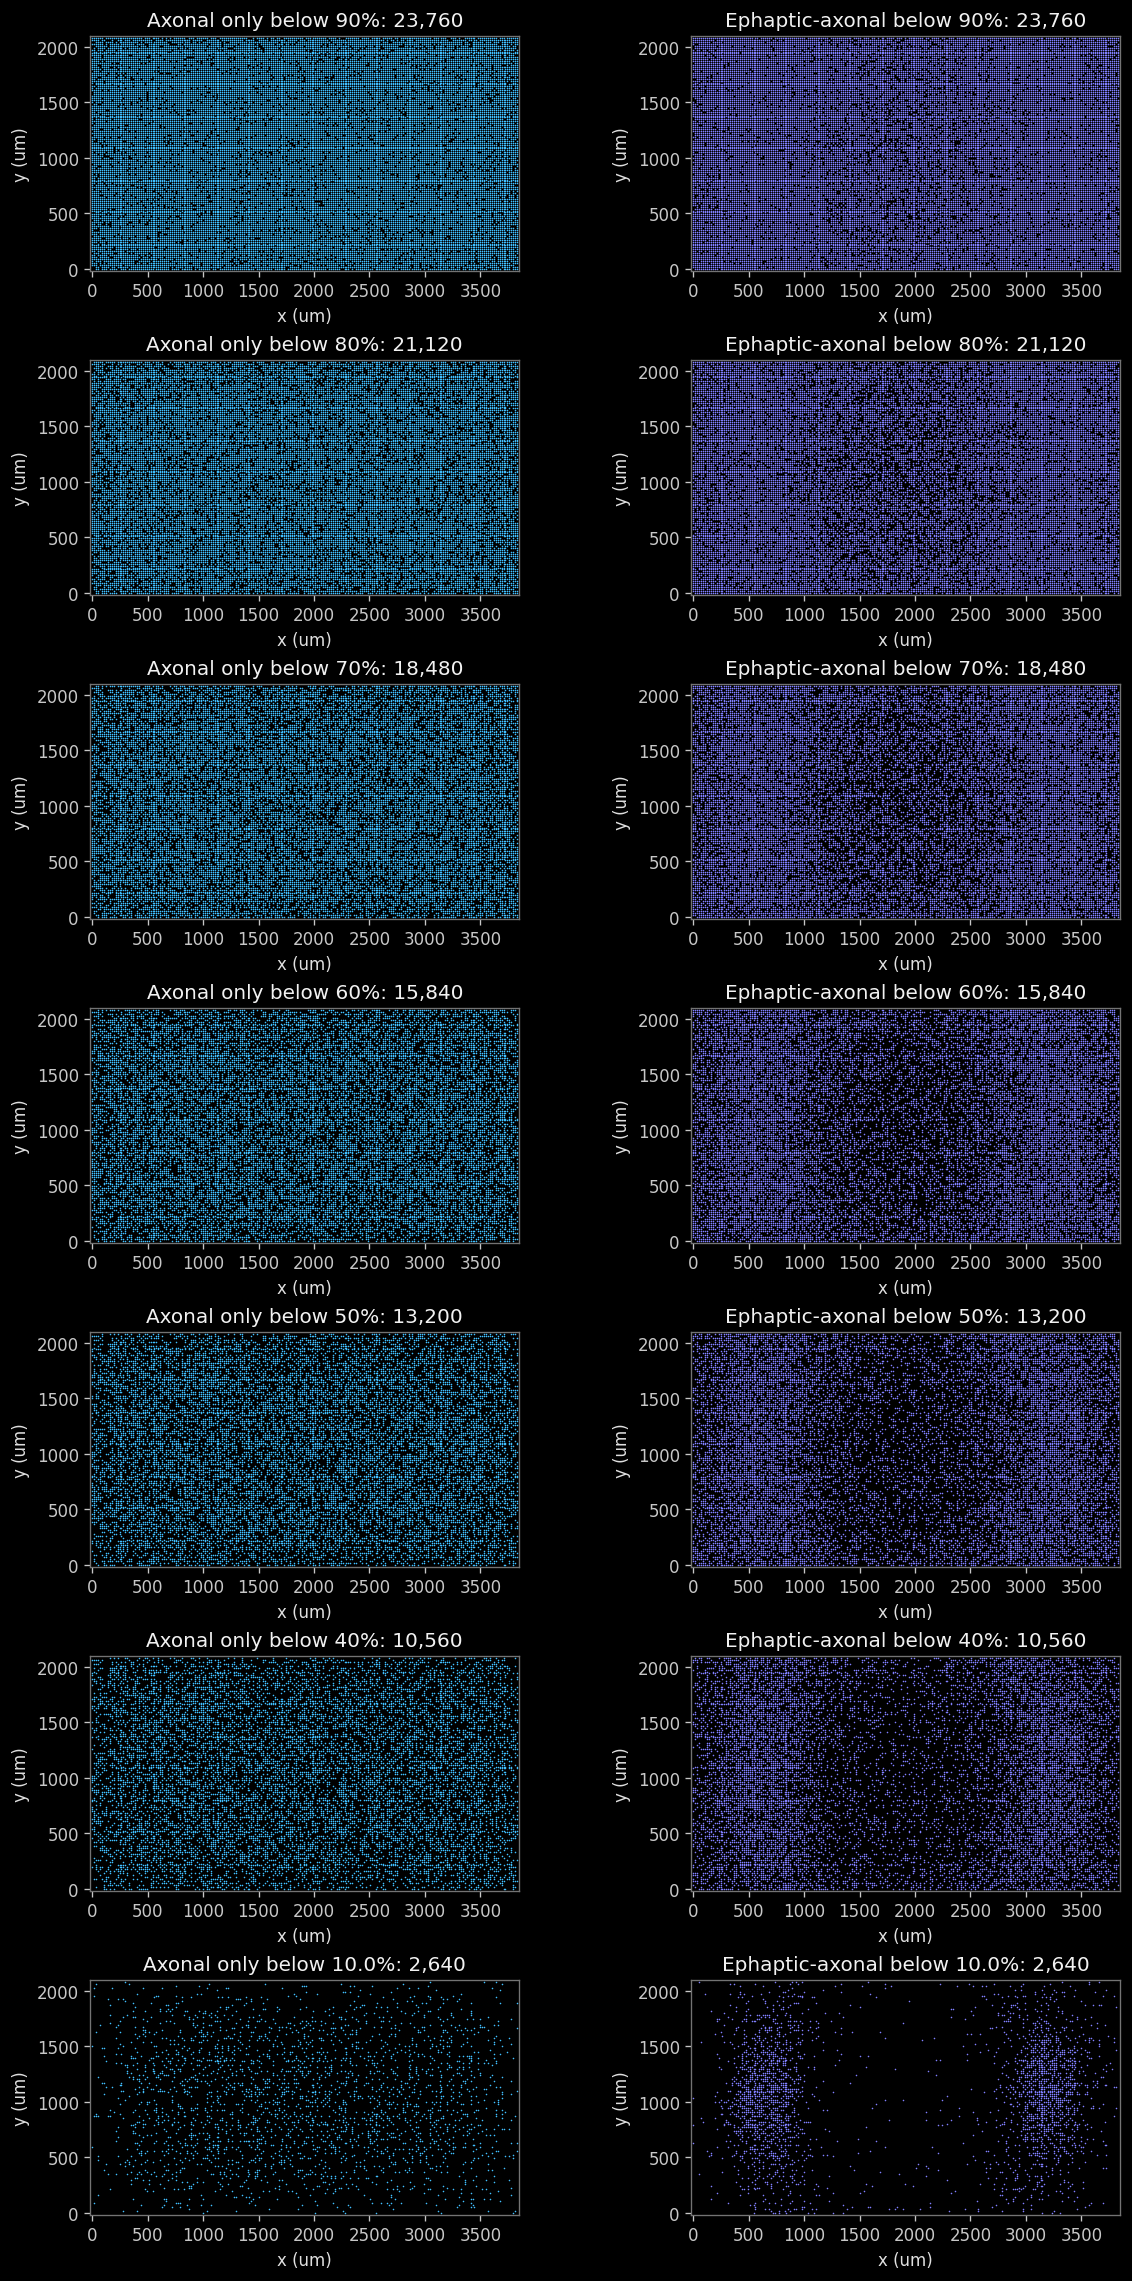

In [9]:
def plot_milestone_maps(
    simulation_results,
    labels,
    *,
    rows_per_figure=MILESTONE_PLOT_ROWS_PER_FIG,
    model_order=None,
    point_size=0.9,
):
    labels = list(labels)
    model_order = list(simulation_results) if model_order is None else list(model_order)
    rows_per_figure = max(1, int(rows_per_figure))

    for start in range(0, len(labels), rows_per_figure):
        chunk = labels[start : start + rows_per_figure]
        fig, axes = plt.subplots(
            len(chunk),
            len(model_order),
            figsize=(5.0 * len(model_order), 2.7 * len(chunk)),
            squeeze=False,
            constrained_layout=True,
        )

        for row_idx, label in enumerate(chunk):
            for col_idx, key in enumerate(model_order):
                result = simulation_results[key]
                nodes = result["milestone_snapshots"][label]
                plot_node_map(
                    axes[row_idx, col_idx],
                    nodes,
                    f"{result['model']} below {label}: {len(nodes):,}",
                    point_size=point_size,
                    color=MODEL_COLORS[key],
                )
        plt.show()


plot_milestone_maps(simulation_results, ordered_labels)
